In [1]:
from pprint import pprint
from collections import Counter, defaultdict
import re
import json

from matplotlib import pyplot
import pandas as pd

from brickmapper import Mapper
from brickmapper.bedes_parser.bedes_parser import BedesParser
from brickmapper.buildingsync.buildingsync_parser import BuildingSyncParser


In [2]:
"""Get 229P defns"""
with open('brickmapper/229P_parser/schema_definitions.json', 'r') as file:
    data = json.load(file)
    _229p_defns = list(data.values())
    _229p_defns = [
        {
            "name": n.split("/")[-1],
            "tree": d["tree"],
            "definition": d["description"],
        }
        for n, d in data.items()
    ]

pprint(_229p_defns)

[{'definition': '', 'name': 'Timestamp', 'tree': '/Timestamp'},
 {'definition': '',
  'name': 'RulesetProjectDescription',
  'tree': '/RulesetProjectDescription'},
 {'definition': 'Scope-unique reference identifier for instances of this data '
                'group.',
  'name': 'id',
  'tree': '/RulesetProjectDescription/id'},
 {'definition': 'Descriptive name used in RCT reports if id is not already a '
                'descriptive name',
  'name': 'reporting_name',
  'tree': '/RulesetProjectDescription/reporting_name'},
 {'definition': 'Supplementary information to provide context to the model '
                'reviewer',
  'name': 'notes',
  'tree': '/RulesetProjectDescription/notes'},
 {'definition': 'A list of the ruleset model descriptions within the project '
                'each with a unique ruleset_model_type.',
  'name': 'ruleset_model_descriptions',
  'tree': '/RulesetProjectDescription/ruleset_model_descriptions'},
 {'definition': 'Metadata',
  'name': 'metadata',
  'tr

In [3]:
"""Get BuildingSync defns"""
buildingsync_parser = BuildingSyncParser()
buildingsync_defns = buildingsync_parser._get_term_definitions()

pprint(buildingsync_defns)

[{'definition': '', 'name': 'BuildingSync', 'tree': '/xs:schema/xs:element[1]'},
 {'definition': '',
  'name': 'Programs',
  'tree': '/xs:schema/xs:element[1]/xs:complexType/xs:sequence/xs:element[1]'},
 {'definition': 'Authorized or supported program such as rebate or audit.',
  'name': 'Program',
  'tree': '/xs:schema/xs:element[1]/xs:complexType/xs:sequence/xs:element[1]/xs:complexType/xs:sequence/xs:element'},
 {'definition': 'Date associated with the program.',
  'name': 'ProgramDate',
  'tree': '/xs:schema/xs:element[1]/xs:complexType/xs:sequence/xs:element[1]/xs:complexType/xs:sequence/xs:element/xs:complexType/xs:sequence/xs:element[1]'},
 {'definition': 'The source of funding or sponsor of the program.',
  'name': 'ProgramFundingSource',
  'tree': '/xs:schema/xs:element[1]/xs:complexType/xs:sequence/xs:element[1]/xs:complexType/xs:sequence/xs:element/xs:complexType/xs:sequence/xs:element[2]'},
 {'definition': 'The classification or type of the program.',
  'name': 'ProgramClas

In [4]:
"""Create Mapper"""
mapper = Mapper(
    first_definitions=[{"name": d["name"]} for d in buildingsync_defns],
    first_index_file="./indices/names/buidingsync.ollama.index",
    second_definitions=[{"name": d["name"]} for d in _229p_defns],
    second_index_file="./indices/names/229P.ollama.index",
)

2025-02-26 15:45:10.859 | INFO     | brickmapper:populate_external_embeddings:48 - Restoring ./indices/names/buidingsync.ollama.index...
2025-02-26 15:45:10.880 | INFO     | brickmapper:populate_external_embeddings:48 - Restoring ./indices/names/229P.ollama.index...


In [5]:
"""Get Mappings"""
top_k = 3
threshold = .3
results = mapper.get_mappings_with_collisions(top_k, threshold)

pd.DataFrame(
    [[name, *r] for name, r in results.items()], 
    columns=["BuildingSync Term", "#1 Best Match", "#2 Best Match", "#3 Best Match"]
).to_excel("229-names-results.xlsx")

results

{'BuildingSync': [('BuildingSegment', np.float32(0.28)),
  ('Building', np.float32(0.29)),
  ('type#BUILDING_FACADE', np.float32(0.3))],
 'Programs': [('Schedule', np.float32(0.29))],
 'Program': [('Schedule', np.float32(0.25))],
 'ProgramDate': [],
 'ProgramFundingSource': [],
 'ProgramClassification#Audit': [],
 'ProgramClassification#Performance': [],
 'ProgramClassification#Deemed': [('classification', np.float32(0.29)),
  ('classification#WINDOW', np.float32(0.3))],
 'ProgramClassification#Retrofit': [],
 'ProgramClassification#Rebate': [],
 'ProgramClassification#Other': [('subclassification#OTHER', np.float32(0.16)),
  ('classification#OTHER', np.float32(0.18)),
  ('CommonConstructionClassificationOptions#OTHER', np.float32(0.19))],
 'ProgramClassification#Not Applicable': [('prescribed_type#NOT_APPLICABLE',
   np.float32(0.26))],
 'Facilities': [('buildings', np.float32(0.24)),
  ('Building', np.float32(0.27))],
 'Facility': [('Building', np.float32(0.25)),
  ('location#GARAGE'

the threshold was a distance of 0.3:
	 1564 defintitons had 3 results below threshold
	 278 defintitons had 1 results below threshold
	 1509 defintitons had 0 results below threshold
	 211 defintitons had 2 results below threshold


here are some of the defintions with no matches:
['ProgramDate',
 'ProgramFundingSource',
 'ProgramClassification#Audit',
 'ProgramClassification#Performance',
 'ProgramClassification#Retrofit']


here's a histogram of score, groups by the rank of the match


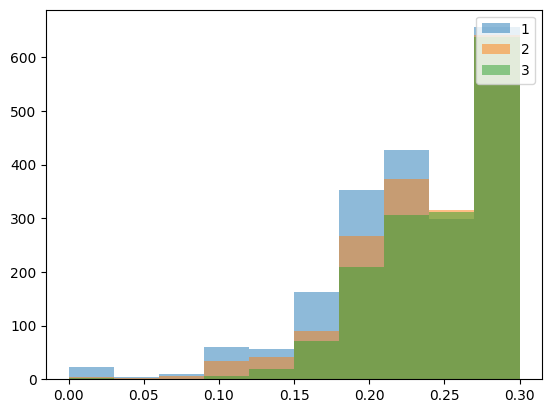

In [6]:
"""Some quick analysis"""

number_of_suggestions_above_threshold = [len(r) for r in results.values()]
print(f"the threshold was a distance of {threshold}:")
for num_results, num_with_num_results in Counter(number_of_suggestions_above_threshold).items():
    print(f"\t {num_with_num_results} defintitons had {num_results} results below threshold")

print("\n\nhere are some of the defintions with no matches:")
pprint([name for name, r in results.items() if len(r) == 0][:5])

scores_by_rank = defaultdict(list)
for r in results.values():
    for rank, (_, score) in enumerate(r):
        scores_by_rank[rank].append(score)

print("\n\nhere's a histogram of score, groups by the rank of the match")
for rank in range(top_k):
    pyplot.hist(scores_by_rank[rank], alpha=0.5, label=rank+1)
    
pyplot.legend(loc='upper right')
pyplot.show()



In [7]:
for rank in range(top_k):
    results_with_rank = [r for r in results.items() if len(r[1]) > rank]
    best_matches = sorted(results_with_rank, key=lambda x: 1 * x[1][rank][1])
    print(f"Some of the best matches for rank {rank + 1} are:")
    pprint([(m[0], m[1][rank]) for m in best_matches[:5]])
    print("\n")


Some of the best matches for rank 1 are:
[('FanSystem', ('FanSystem', np.float32(0.0))),
 ('Schedules', ('schedules', np.float32(0.0))),
 ('Schedule', ('Schedule', np.float32(-0.0))),
 ('Buildings', ('buildings', np.float32(0.0))),
 ('Building', ('Building', np.float32(0.0)))]


Some of the best matches for rank 2 are:
[('Location#Garage', ('location#GARAGE', np.float32(0.0))),
 ('Location#Attic', ('location#ATTIC', np.float32(-0.0))),
 ('Location#Other', ('location#OTHER', np.float32(0.0))),
 ('DehumidificationType#Other',
  ('dehumidification_type#OTHER', np.float32(0.02))),
 ('Schedules', ('Schedule', np.float32(0.05)))]


Some of the best matches for rank 3 are:
[('Location#Garage', ('location#GARAGE', np.float32(0.0))),
 ('Location#Attic', ('location#ATTIC', np.float32(-0.0))),
 ('Location#Other', ('location#OTHER', np.float32(0.0))),
 ('Crawlspace', ('location#CRAWL_SPACE', np.float32(0.08))),
 ('DehumidificationType#Other',
  ('DehumidificationOptions#OTHER', np.float32(0.1)))]


In [8]:
unmatched_terms = [term for term, matches in results.items() if len(matches) == 0]

pprint(unmatched_terms)

['ProgramDate',
 'ProgramFundingSource',
 'ProgramClassification#Audit',
 'ProgramClassification#Performance',
 'ProgramClassification#Retrofit',
 'ProgramClassification#Rebate',
 'Sites',
 'Site',
 'MotorSystems',
 'FoundationSystems',
 'FoundationSystem',
 'CriticalITSystems',
 'ConveyanceSystems',
 'ConveyanceSystem',
 'Tightness',
 'LocationsOfExteriorWaterIntrusionDamage#Interior ceiling',
 'LocationsOfExteriorWaterIntrusionDamage#Foundation',
 'LocationsOfExteriorWaterIntrusionDamage#Basement',
 'LocationsOfExteriorWaterIntrusionDamage#Walls',
 'LocationsOfExteriorWaterIntrusionDamage#Around windows',
 'LocationsOfInteriorWaterIntrusionDamages',
 'LocationsOfInteriorWaterIntrusionDamage#Basement',
 'Measures',
 'Contacts',
 'Contact',
 'Tenant',
 'AuditCycles',
 'AuditCycle',
 'NAICSCode',
 'PubliclySubsidized',
 'Agency',
 'DepartmentRegion',
 'NumberOfBusinesses',
 'HistoricalLandmark',
 'AspectRatio',
 'TotalExteriorAboveGradeWallArea',
 'TotalExteriorBelowGradeWallArea',
 'Ov

In [9]:
set_of_broken_unmatched_terms = set()
for t in unmatched_terms:
    broken_term = re.findall('[A-Z][^A-Z]*', t)
    set_of_broken_unmatched_terms.update(broken_term)

pprint(set_of_broken_unmatched_terms)

{'A',
 'A ',
 'A)',
 'A-series',
 'A-shape',
 'A1',
 'A2',
 'A3',
 'A: ',
 'Above',
 'Above and ',
 'Absorption',
 'Account',
 'Active',
 'Activity',
 'Actual',
 'Add ',
 'Add drive controls',
 'Add or upgrade ',
 'Add or upgrade controls',
 'Add secondary window systems/attachments',
 'Add window films',
 'Added',
 'Addition',
 'Additional',
 'Additional to last billing period',
 'Additions',
 'Address',
 'Addresses',
 'Adjusted',
 'Adjusted to specific year',
 'Adjusted#',
 'Adjustment',
 'Administrator',
 'Advanced',
 'Advanced resource meter',
 'Affected',
 'Affected#',
 'Agency',
 'Agent',
 'Aggregate',
 'Air',
 'Air ',
 'Air changes per hour',
 'Air seal envelope',
 'All',
 'All ',
 'Alley',
 'Alternative',
 'Always ',
 'Amended filing',
 'Amps',
 'Anaerobic biodigester',
 'Analog',
 'Analysis',
 'Ancillary',
 'And',
 'Angle',
 'Annual',
 'Annually',
 'Antenna',
 'Anti',
 'Applicable',
 'Application#',
 'Approved',
 'Arcade',
 'Architect',
 'Area',
 'Argon',
 'Around windows',
 '

In [10]:
seen_broken_unmatched_terms = {t: results[t] for t in set_of_broken_unmatched_terms if t in results}

pprint(f"We have seen {len(seen_broken_unmatched_terms)} of the {len(set_of_broken_unmatched_terms)} broken unmatches terms in the original defintions")
pprint(seen_broken_unmatched_terms)

'We have seen 105 of the 1527 broken unmatches terms in the original defintions'
{'Actual': [],
 'Addition': [],
 'Additions': [],
 'Address': [('location#OUTSIDE', np.float32(0.24)),
             ('location#OUTSIDE', np.float32(0.24)),
             ('location#OUTSIDE', np.float32(0.24))],
 'Agency': [],
 'Analog': [],
 'Assessment': [],
 'Assessments': [],
 'Basement': [('location#UNDERGROUND', np.float32(0.28)),
              ('location#UNDERGROUND', np.float32(0.28)),
              ('location#UNDERGROUND', np.float32(0.28))],
 'Benchmark': [('efficiency_metric_values', np.float32(0.29)),
               ('efficiency_metric_values', np.float32(0.29)),
               ('efficiency_metric_values', np.float32(0.29))],
 'Beta1': [],
 'Beta2': [],
 'Beta3': [],
 'Beta4': [],
 'Building': [('Building', np.float32(0.0)),
              ('buildings', np.float32(0.13)),
              ('Construction', np.float32(0.16))],
 'Capacity': [('capacity', np.float32(-0.0)),
              ('rated_capacity

In [11]:
unseen_broken_unmatched_terms = [t for t in set_of_broken_unmatched_terms if t not in results]

for term in unseen_broken_unmatched_terms[:10]:
    print(term)
    pprint(mapper.get_mappings_for_single_definition({"name": term, 'term_definition': ''}))
    

Length
[('length', np.float32(0.0)),
 ('length', np.float32(0.0)),
 ('length', np.float32(0.0))]
Replace tankless coil
[('heating_coil_setpoint', np.float32(0.3551492)),
 ('heating_coil_setpoint', np.float32(0.3551492)),
 ('heating_coil_setpoint', np.float32(0.3551492))]
Discrete
[('id', np.float32(0.3444584)),
 ('id', np.float32(0.3444584)),
 ('id', np.float32(0.3444584))]
Equipment
[('miscellaneous_equipment', np.float32(0.13062626)),
 ('equipment_category#OTHER', np.float32(0.1324417)),
 ('MiscellaneousEquipment', np.float32(0.17503119))]
Cape
[('Surface', np.float32(0.386896)),
 ('area', np.float32(0.39016366)),
 ('area', np.float32(0.39016366))]
Prismatic 
[('subclassification#SPANDREL_GLASS', np.float32(0.31515926)),
 ('type', np.float32(0.33856165)),
 ('subclassification#GLASS_BLOCK', np.float32(0.36358017))]
Knoll
[('location#OUTSIDE', np.float32(0.42314845)),
 ('location#OUTSIDE', np.float32(0.42314845)),
 ('location#OUTSIDE', np.float32(0.42314845))]
Bluffs
[('surfaces', np.f